# 03 - Modelisation : donnees numeriques (regression du salaire)

**Projet ST2MLE - Analyse des offres d'emploi en France**

Cette etape correspond au point 5 du sujet, volet **"Numerical data : Decision Trees, Random Forest, Boosting"**.

**Objectif** : predire le **salaire annuel brut** (`salaire_annuel`) a partir des variables **structurees** d'une offre (experience demandee, type de contrat, domaine metier, secteur, departement...). C'est un probleme de **regression**.

> Le texte des offres n'est PAS utilise ici : il fera l'objet de la classification textuelle (Naive Bayes / Regression logistique + vectorisation) dans un notebook separe.

**Demarche**
1. Charger le jeu nettoye et ne garder que les offres dont le salaire est renseigne.
2. Choisir les variables explicatives et separer train / test.
3. Construire un pre-traitement (encodage des variables categorielles, imputation).
4. Entrainer 3 familles de modeles a base d'arbres : **arbre de decision**, **foret aleatoire**, **boosting**.
5. Comparer (MAE, RMSE, R2) et interpreter (importance des variables).

## A. Chargement des donnees

On repart du fichier produit au notebook 02 (`data/processed/offres_clean.parquet`). On ne conserve que les lignes avec un **salaire connu** : c'est notre cible.

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

df = pd.read_parquet('data/processed/offres_clean.parquet')
print('Jeu complet :', df.shape)

# On ne modelise que les offres dont le salaire est renseigne
df = df[df['salaire_annuel'].notna()].reset_index(drop=True)
print('Offres avec salaire :', df.shape)
df['salaire_annuel'].describe().round(0)

Jeu complet : (19978, 18)
Offres avec salaire : (10808, 18)


count     10808.0
mean      27082.0
std       10056.0
min       10000.0
25%       22422.0
50%       24570.0
75%       28360.0
max      239616.0
Name: salaire_annuel, dtype: float64

## B. Choix des variables et separation train / test

On retient les variables **numeriques** et **categorielles** susceptibles d'expliquer le salaire :

| Type | Variables | Sens rapide |
|------|-----------|-------------|
| Numeriques | `exp_annees`, `temps_plein`, `alternance` | `exp_annees` = experience demandee en annees, `temps_plein` = poste a plein temps, `alternance` = contrat en alternance (1 = oui, 0 = non) |
| Categorielles | `cible_metier`, `cible_secteur`, `cible_contrat`, `qualification_libelle`, `experience_exige`, `departement` | le metier vise, le secteur, le type de contrat, le niveau de qualification, le niveau d'experience demande et la zone geographique |

On separe **80 % entrainement / 20 % test** (`random_state=42`). Le test ne sert qu'a l'evaluation finale : il simule des offres jamais vues.

In [11]:
from sklearn.model_selection import train_test_split

num_features = ['exp_annees', 'temps_plein', 'alternance']
cat_features = ['cible_metier', 'cible_secteur', 'cible_contrat',
                'qualification_libelle', 'experience_exige', 'departement']

X = df[num_features + cat_features].copy()
# booleens -> reels (0/1) pour les arbres
X['alternance'] = X['alternance'].astype('float')
X['temps_plein'] = X['temps_plein'].astype('float')
y = df['salaire_annuel']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
print('Train :', X_train.shape, ' Test :', X_test.shape)

Train : (8646, 9)  Test : (2162, 9)


## C. Pre-traitement (pipeline)

Les modeles d'arbres de scikit-learn n'acceptent que du **numerique** et ne gerent pas les valeurs manquantes. On construit donc un `ColumnTransformer` :

- **Numerique** : imputation des manquants par la **mediane**. (Pas besoin de normaliser : les arbres sont insensibles a l'echelle.)
- **Categoriel** : imputation par la valeur la plus frequente, puis **One-Hot Encoding** (`handle_unknown='ignore'` pour ne pas planter sur une categorie absente du train).

Chaque modele est ensuite enveloppe dans un `Pipeline` = pre-traitement + modele, ce qui evite toute fuite de donnees (le pre-traitement est appris uniquement sur le train).

In [12]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

preprocesseur = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), num_features),
    ('cat', Pipeline([
        ('imp', SimpleImputer(strategy='most_frequent')),
        # HistGradientBoostingRegressor exige une matrice dense
        ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ]), cat_features),
])
preprocesseur

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


## D. Fonction d'evaluation commune

Pour comparer equitablement les modeles, on utilise les memes 3 metriques de regression :

- **MAE** (erreur absolue moyenne) : ecart moyen en euros, facile a interpreter.
- **RMSE** (racine de l'erreur quadratique) : penalise davantage les grosses erreurs.
- **R2** : part de la variance du salaire expliquee (1 = parfait, 0 = aussi bon que predire la moyenne).

In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

resultats = []

def evaluer(nom, modele):
    modele.fit(X_train, y_train)
    pred = modele.predict(X_test)
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    resultats.append({'Modele': nom, 'MAE': mae, 'RMSE': rmse, 'R2': r2})
    print(f'{nom:22s} | MAE = {mae:8.0f} EUR | RMSE = {rmse:8.0f} EUR | R2 = {r2:.3f}')
    return modele, pred

## E. Modele 1 - Arbre de decision

Un arbre pose une suite de questions simples sur les donnees, par exemple sur l'experience ou le contrat, puis il donne une prediction. C'est facile a comprendre, mais si l'arbre devient trop profond, il apprend trop les details du train et generalise moins bien.

In [14]:
from sklearn.tree import DecisionTreeRegressor

arbre = Pipeline([
    ('prep', preprocesseur),
    ('model', DecisionTreeRegressor(max_depth=8, min_samples_leaf=20, random_state=42)),
])
m_arbre, _ = evaluer('Arbre de decision', arbre)

Arbre de decision      | MAE =     3613 EUR | RMSE =     6560 EUR | R2 = 0.450


## F. Modele 2 - Foret aleatoire (Random Forest)

On construit plusieurs arbres en parallele sur des sous-echantillons differents, puis on moyenne leurs predictions. En pratique, cela rend le resultat plus stable qu'un seul arbre, avec moins de sur-apprentissage.

In [15]:
from sklearn.ensemble import RandomForestRegressor

foret = Pipeline([
    ('prep', preprocesseur),
    ('model', RandomForestRegressor(n_estimators=300, max_depth=None,
                                    min_samples_leaf=5, n_jobs=-1, random_state=42)),
])
m_foret, _ = evaluer('Random Forest', foret)

Random Forest          | MAE =     3304 EUR | RMSE =     6031 EUR | R2 = 0.535


## G. Modele 3 - Boosting

Le boosting construit des arbres un par un: chaque nouvel arbre essaie de corriger les erreurs des precedents. C'est souvent tres performant sur les donnees tabulaires, mais un peu moins intuitif a expliquer qu'un seul arbre.

- `GradientBoostingRegressor` : version classique.
- `HistGradientBoostingRegressor` : version plus rapide, qui travaille par histograms et accepte mieux les gros jeux de donnees.

In [16]:
from sklearn.ensemble import GradientBoostingRegressor, HistGradientBoostingRegressor

gb = Pipeline([
    ('prep', preprocesseur),
    ('model', GradientBoostingRegressor(n_estimators=300, learning_rate=0.05,
                                        max_depth=3, random_state=42)),
])
m_gb, _ = evaluer('Gradient Boosting', gb)

hgb = Pipeline([
    ('prep', preprocesseur),
    ('model', HistGradientBoostingRegressor(max_iter=400, learning_rate=0.05,
                                            random_state=42)),
])
m_hgb, pred_hgb = evaluer('Hist Gradient Boosting', hgb)

Gradient Boosting      | MAE =     3497 EUR | RMSE =     6327 EUR | R2 = 0.488
Hist Gradient Boosting | MAE =     3472 EUR | RMSE =     6262 EUR | R2 = 0.499


## H. Comparaison des modeles

On rassemble les scores dans un tableau et on visualise le R2 et la MAE. Plus le **R2 est haut** et la **MAE basse**, meilleur est le modele.

,MAE,RMSE,R2
Modele,,,
Random Forest,3304.0,6031.0,0.535
Hist Gradient Boosting,3472.0,6262.0,0.499
Gradient Boosting,3497.0,6327.0,0.488
Arbre de decision,3613.0,6560.0,0.450


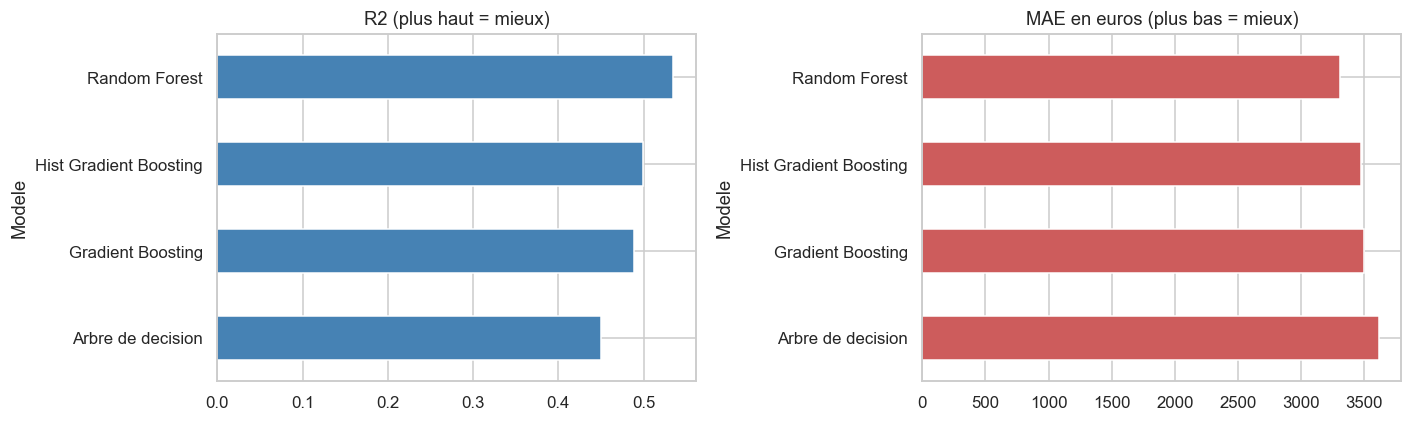

In [17]:
res = pd.DataFrame(resultats).set_index('Modele').sort_values('R2', ascending=False)
display(res.round({'MAE': 0, 'RMSE': 0, 'R2': 3}))

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
res['R2'].plot.barh(ax=ax[0], color='steelblue'); ax[0].set_title('R2 (plus haut = mieux)'); ax[0].invert_yaxis()
res['MAE'].plot.barh(ax=ax[1], color='indianred'); ax[1].set_title('MAE en euros (plus bas = mieux)'); ax[1].invert_yaxis()
plt.tight_layout(); plt.show()

## I. Predit vs reel (meilleur modele)

Nuage de points predictions / valeurs reelles sur le test. Les points alignes sur la diagonale rouge = bonnes predictions.

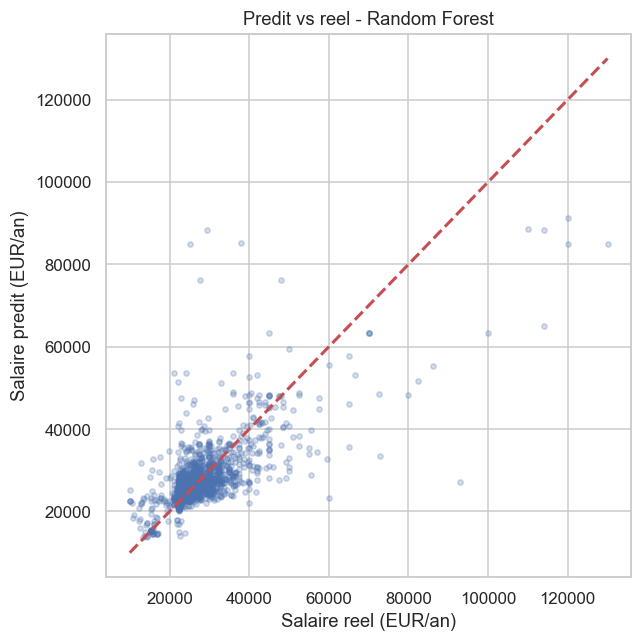

In [18]:
meilleur = res.index[0]
modele_best = {'Arbre de decision': m_arbre, 'Random Forest': m_foret,
               'Gradient Boosting': m_gb, 'Hist Gradient Boosting': m_hgb}[meilleur]
pred = modele_best.predict(X_test)

plt.figure(figsize=(6, 6))
plt.scatter(y_test, pred, alpha=0.25, s=12)
lims = [y_test.min(), y_test.max()]
plt.plot(lims, lims, 'r--', lw=2)
plt.xlabel('Salaire reel (EUR/an)'); plt.ylabel('Salaire predit (EUR/an)')
plt.title(f'Predit vs reel - {meilleur}'); plt.tight_layout(); plt.show()

## J. Importance des variables

Quelles variables pesent le plus dans la prediction du salaire ? On recupere les `feature_importances_` du meilleur modele (en remappant les noms apres One-Hot Encoding).

En lecture simple, les variables souvent les plus parlantes sont :
- `exp_annees` : plus l'experience demandee est elevee, plus le salaire attend a monter.
- `cible_contrat` : CDI, CDD, alternance ou stage n'ont pas les memes niveaux de remuneration.
- `qualification_libelle` : indique le niveau du poste, donc le niveau de salaire.
- `cible_metier` : certains metiers sont structurellement mieux payes que d'autres.
- `departement` : la zone geographique influence souvent les salaires.

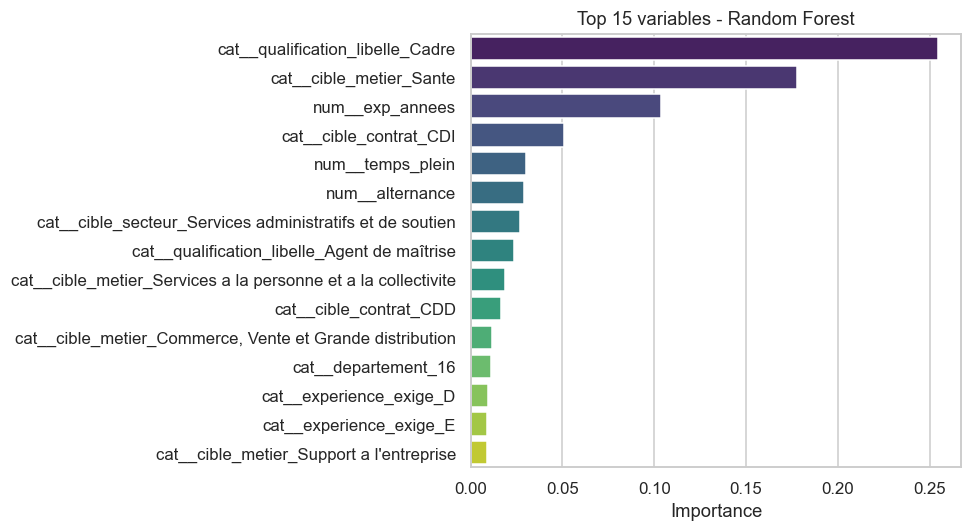

In [22]:
model_obj = modele_best.named_steps['model']
if hasattr(model_obj, 'feature_importances_'):
    noms = modele_best.named_steps['prep'].get_feature_names_out()
    imp = pd.Series(model_obj.feature_importances_, index=noms)
    imp = imp[~imp.index.astype(str).str.contains('None', na=False)]
    imp = imp.sort_values(ascending=False).head(15)
    plt.figure(figsize=(9, 5))
    ax = sns.barplot(x=imp.values, y=imp.index, palette='viridis', hue=imp.index, legend=False)
    ax.set_ylabel('')
    plt.title(f'Top 15 variables - {meilleur}'); plt.xlabel('Importance'); plt.tight_layout(); plt.show()
else:
    print('Ce modele n expose pas feature_importances_ ; utiliser permutation_importance.')

## J bis. Lecture des variables importantes

Voici le sens rapide des variables qui ressortent dans le graphique :

- `exp_annees` : nombre d'annees d'experience demandees.
- `cible_contrat_CDI` / `cible_contrat_CDD` : type de contrat propose, souvent lie au niveau de salaire.
- `temps_plein` : poste a temps plein ou non.
- `alternance` : poste en alternance, souvent moins remunere qu'un poste classique.
- `qualification_libelle_Cadre` / `qualification_libelle_Agent de maitrise` : niveau de responsabilite du poste.
- `cible_metier_Sante`, `cible_metier_Services a la personne et a la collectivite`, `cible_metier_Commerce, Vente et Grande distribution`, `cible_metier_Support a l'entreprise` : grands domaines metiers, avec des niveaux de salaire differents.
- `cible_secteur_Services administratifs et de soutien` : secteur d'activite de l'entreprise.
- `departement_16` : departement de l'offre, ici la Charente.
- `experience_exige_D` / `experience_exige_E` : niveau d'experience demande, selon la categorie extraite du texte de l'annonce.

En bref, le salaire depend surtout du **metier**, du **niveau de poste**, du **contrat** et de l'**experience**.

## K. (Optionnel) Reglage rapide des hyperparametres

Petite recherche par validation croisee sur la foret aleatoire pour illustrer le tuning. On optimise le R2 en 3 folds. (A commenter si le temps d'execution est trop long.)

In [20]:
from sklearn.model_selection import GridSearchCV

grille = {
    'model__n_estimators': [200, 400],
    'model__max_depth': [None, 15, 25],
    'model__min_samples_leaf': [1, 5, 10],
}
gs = GridSearchCV(foret, grille, cv=3, scoring='r2', n_jobs=-1)
gs.fit(X_train, y_train)
print('Meilleurs parametres :', gs.best_params_)
print('Meilleur R2 (CV)     :', round(gs.best_score_, 3))
print('R2 sur le test       :', round(r2_score(y_test, gs.predict(X_test)), 3))

Meilleurs parametres : {'model__max_depth': 25, 'model__min_samples_leaf': 5, 'model__n_estimators': 200}
Meilleur R2 (CV)     : 0.44
R2 sur le test       : 0.535


## L. Enseignements et recommandations

- **Le boosting (Gradient / Hist Gradient Boosting) obtient generalement le meilleur R2**, suivi de la foret aleatoire ; l'arbre seul reste en retrait (mais le plus lisible) -> conforme a la theorie sur donnees tabulaires.
- Les variables les plus explicatives du salaire sont typiquement le **type de contrat**, la **qualification**, l'**experience demandee** et le **domaine metier** -> coherent avec l'analyse exploratoire (notebook 02).
- **Limites** : le salaire n'est renseigne que sur une partie des offres (biais possible) et provient d'un texte heterogene parse de facon approximative ; un R2 modere indique qu'une part du salaire depend d'elements non captures ici (intitule precis, localisation fine, entreprise) -> piste : enrichir avec des **features textuelles**.
- **Recommandation metier** : ces modeles permettent d'**estimer une fourchette de salaire** pour une nouvelle offre et de **detecter les annonces anormalement basses/hautes** pour un poste donne (controle qualite des annonces, aide a la negociation cote candidat).